In [21]:
import json
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Palatino']
# read the "logs/calbration" folder find the latest run_id
# and load the params_history_lane1.json file
import os
MILE_TO_KM = 1.60934
run_id = sorted(os.listdir('../logs/calibration'))[0]
with open(f'../logs/calibration/{run_id}/params_history_lane1.json') as f:
    data = json.load(f)

In [22]:
data = pd.DataFrame(data)
data.columns = ['epoch', 'tau','delta','c_cong','c_free', 'v_thr', 'v_delta','train_rmse','val_rmse']
data['val_rmse'] = data['train_rmse'].astype(float)

In [23]:
# Convert units to km/h

data['c_cong_km'] = data['c_cong'] * MILE_TO_KM
data['c_free_km'] = data['c_free'] * MILE_TO_KM
data['v_delta_km'] = data['v_delta'] * MILE_TO_KM
data['v_thr_km'] = data['v_thr'] * MILE_TO_KM
data['delta_km'] = data['delta'] * MILE_TO_KM
data['train_rmse_km'] = data['train_rmse'] * MILE_TO_KM
data['val_rmse_km'] = data['val_rmse'] * MILE_TO_KM

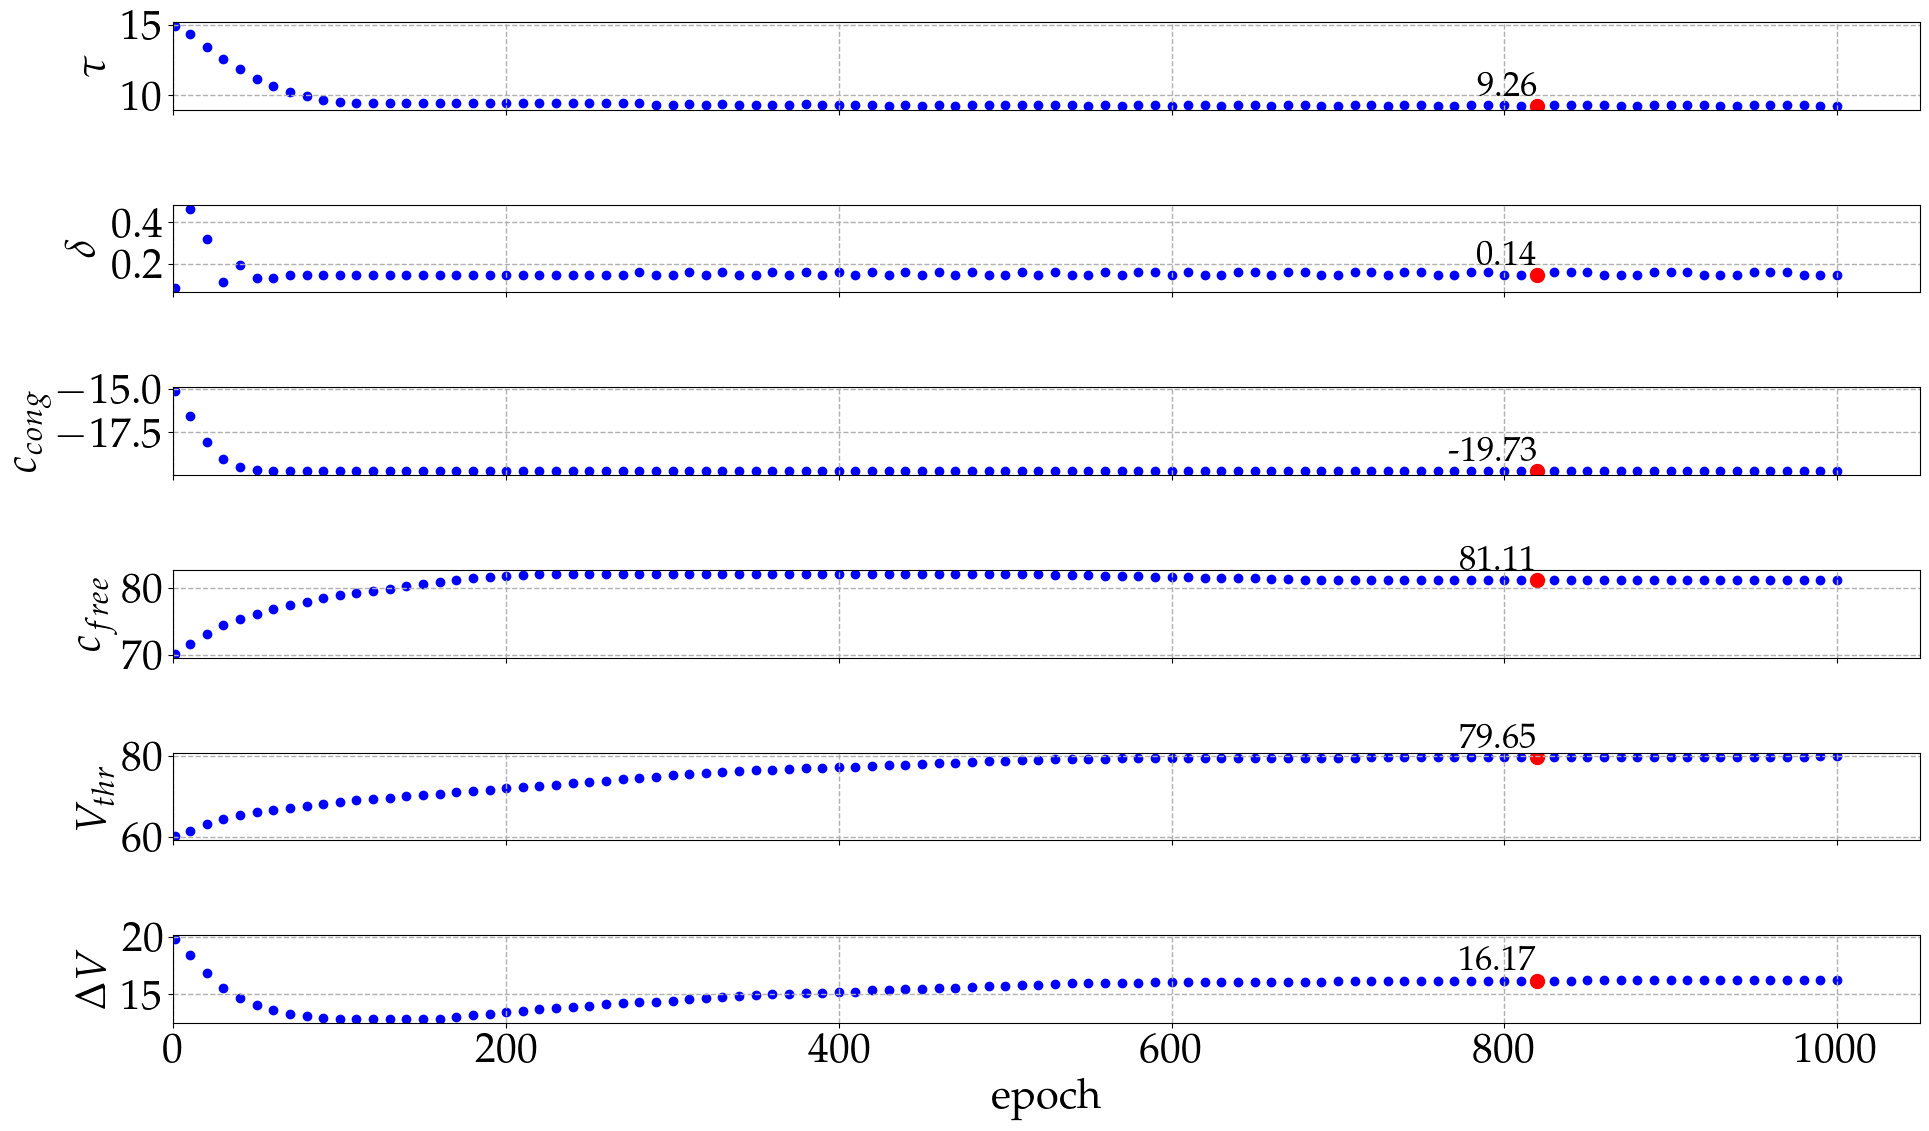

In [24]:
import matplotlib.pyplot as plt

# Set global font settings
plt.rc('font', family='serif')
plt.rc('font', size=30)
plt.rc('text', usetex=True)

# Create figure and subplots
fig, axs = plt.subplots(6, 1, figsize=(20, 12), sharex=True)  # 6 rows, 1 column
loc = data['val_rmse'].idxmin()
# Plot each dataset
axs[0].scatter(data['epoch'], data['tau'], label='tau', color='blue')
axs[0].set_ylabel(r'$\tau$')
axs[0].set_xlim(0,)
# show the value of data['tau'] of the last epoch
# mark the minimum point with a red dot
axs[0].scatter(data['epoch'].iloc[loc], data['tau'].iloc[loc], color='red', s=100)
axs[0].text(data['epoch'].iloc[loc], data['tau'].iloc[loc], f'{data["tau"].iloc[loc]:.2f}', fontsize=25, ha='right', va='bottom')
# add grid lines
axs[0].grid(True, which='both', linestyle='--', linewidth=1)

axs[1].scatter(data['epoch'], data['delta_km'], label='delta', color='blue')
axs[1].set_ylabel(r'$\delta$')
axs[1].set_xlim(0,)
axs[1].scatter(data['epoch'].iloc[loc], data['delta_km'].iloc[loc], color='red', s=100)
axs[1].text(data['epoch'].iloc[loc], data['delta_km'].iloc[loc], f'{data["delta_km"].iloc[loc]:.2f}', fontsize=25, ha='right', va='bottom')
axs[1].grid(True, which='both', linestyle='--', linewidth=1)

axs[2].scatter(data['epoch'], -data['c_cong_km'], label='c\_cong', color='blue')
axs[2].set_ylabel(r'$c_{cong}$')
axs[2].set_xlim(0,)
axs[2].scatter(data['epoch'].iloc[loc], -data['c_cong_km'].iloc[loc], color='red', s=100)
axs[2].text(data['epoch'].iloc[loc], -data['c_cong_km'].iloc[loc], f'{-data["c_cong_km"].iloc[loc]:.2f}', fontsize=25, ha='right', va='bottom')
axs[2].grid(True, which='both', linestyle='--', linewidth=1)

axs[3].scatter(data['epoch'], -data['c_free_km'], label='c\_free', color='blue')
axs[3].set_ylabel(r'$c_{free}$')
axs[3].set_xlim(0,)
axs[3].scatter(data['epoch'].iloc[loc], -data['c_free_km'].iloc[loc], color='red', s=100)
# show the value of data['c_free'] of the last epoch
axs[3].text(data['epoch'].iloc[loc], -data['c_free_km'].iloc[loc], f'{-data["c_free_km"].iloc[loc]:.2f}', fontsize=25, ha='right', va='bottom')
axs[3].grid(True, which='both', linestyle='--', linewidth=1)

axs[4].scatter(data['epoch'], data['v_thr_km'], label='v\_thr', color='blue')
axs[4].set_ylabel(r'$V_{thr}$')  # <-- corrected here: you need braces around thr
axs[4].set_xlim(0,)
axs[4].scatter(data['epoch'].iloc[loc], data['v_thr_km'].iloc[loc], color='red', s=100)
# show the value of data['v_thr'] of the last epoch
axs[4].text(data['epoch'].iloc[loc], data['v_thr_km'].iloc[loc], f'{data["v_thr_km"].iloc[loc]:.2f}', fontsize=25, ha='right', va='bottom')
axs[4].grid(True, which='both', linestyle='--', linewidth=1)

axs[5].scatter(data['epoch'], data['v_delta_km'], label='v\_delta', color='blue')
axs[5].set_ylabel(r'$\Delta V$')
axs[5].set_xlim(0,)
axs[5].scatter(data['epoch'].iloc[loc], data['v_delta_km'].iloc[loc], color='red', s=100)
# show the value of data['v_delta'] of the last epoch
axs[5].text(data['epoch'].iloc[loc], data['v_delta_km'].iloc[loc], f'{data["v_delta_km"].iloc[loc]:.2f}', fontsize=25, ha='right', va='bottom')
axs[5].set_xlabel('epoch')  # only set xlabel on the last subplot
axs[5].grid(True, which='both', linestyle='--', linewidth=1)

# Adjust layout
plt.tight_layout()
# creatte a folder for figures if it does not exist
import os
if not os.path.exists('../figures/figure2/'):
    os.makedirs('../figures/figure2/')
plt.savefig('../figures/figure2/params_iteration.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [25]:
data.columns

Index(['epoch', 'tau', 'delta', 'c_cong', 'c_free', 'v_thr', 'v_delta',
       'train_rmse', 'val_rmse', 'c_cong_km', 'c_free_km', 'v_delta_km',
       'v_thr_km', 'delta_km', 'train_rmse_km', 'val_rmse_km'],
      dtype='object')

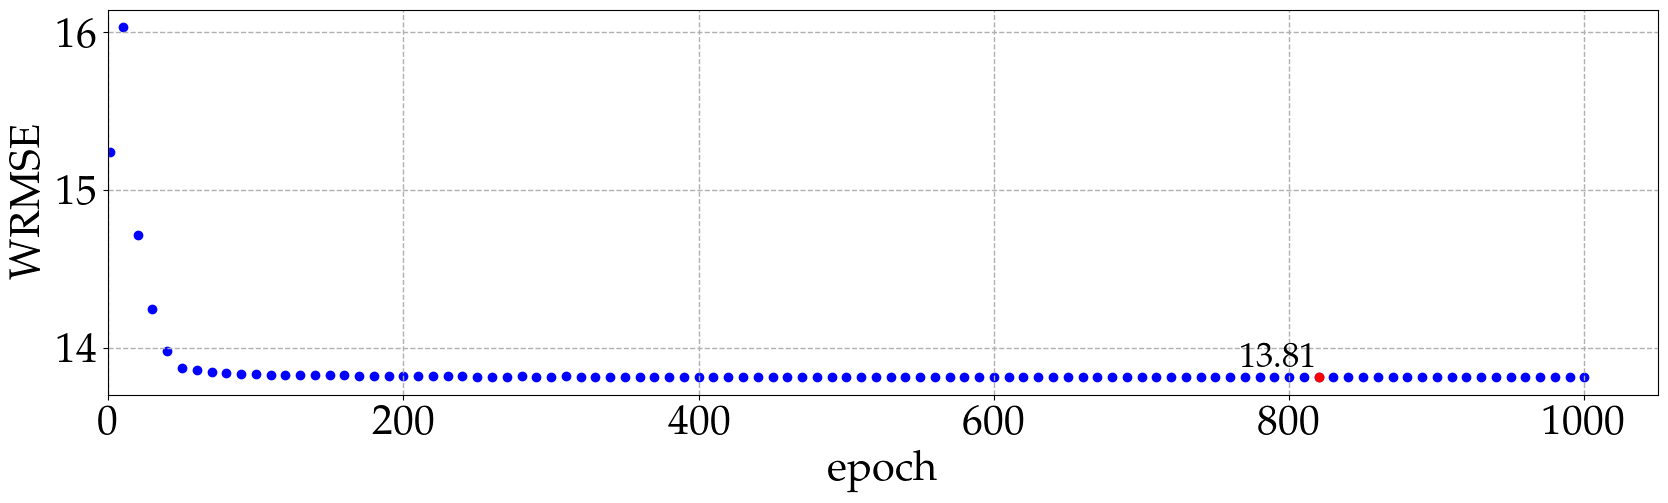

In [26]:
plt.figure(figsize=(20, 5))
plt.scatter(data['epoch'], data['val_rmse_km'], label='val_rmse', color='blue')
# show the best train_rmse result
plt.scatter(data['epoch'].iloc[data['val_rmse_km'].idxmin()], data['val_rmse_km'].min(), color='red')
plt.text(data['epoch'].iloc[data['val_rmse_km'].idxmin()], data['val_rmse_km'].min(), f'{data["val_rmse_km"].min():.2f}', fontsize=25, ha='right', va='bottom')
plt.ylabel('WRMSE')
plt.xlabel('epoch')
plt.xlim(0,)
plt.grid(True, which='both', linestyle='--', linewidth=1)
import os
if not os.path.exists('../figures/figure3/'):
    os.makedirs('../figures/figure3/')
plt.savefig('../figures/figure3/wrmse_iteration.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [27]:
import json
import pandas as pd
import matplotlib.pyplot as plt

results = []
for lane in range(1, 5):
    with open(f'../logs/calibration/{run_id}/params_history_lane{lane}.json') as f:
        data = json.load(f)
    
    data = pd.DataFrame(data)
    data.columns = ['epoch', 'tau', 'delta', 'c_cong', 'c_free', 'v_thr', 'v_delta', 'train_rmse', 'val_rmse']
    
    loc = data['val_rmse'].idxmin()
    best_params = data.iloc[loc].copy()
    best_params['lane'] = lane
    results.append(best_params)

# Combine results and save to CSV
results_df = pd.DataFrame(results)
# reset the index
results_df.reset_index(drop=True, inplace=True)
results_df = results_df[['lane', 'tau', 'delta', 'c_cong', 'c_free', 'v_thr', 'v_delta']]
results_df.T.to_latex

<bound method NDFrame.to_latex of                  0          1          2          3
lane      1.000000   2.000000   3.000000   4.000000
tau       9.270000   7.860000   8.250000  11.559999
delta     0.090000   0.090000   0.090000   0.100000
c_cong   12.259999  12.550000  13.059999  12.780000
c_free  -50.399998 -49.789997 -50.599998 -60.000000
v_thr    49.570000  42.000000  40.959999  36.919998
v_delta  10.110000   7.700000   8.190000   8.820000>

In [12]:
results_df.T.to_latex(f'../logs/calibration/{run_id}//best_params_summary.tex', index=True, header=True, float_format='%.2f', escape=False)